# KNOW DIABETES-A Data Driven Approach to Early Detection-CAPSTONE PROJECT ##

# **Table of Contents**

- [Introduction](#introduction)
- [Setup](#setup)

**1) Baseline Model — Logistic Regression**
- [Stratify Split](#stratify-split)
- [Feature Engineering — Standard Scaler](#feature-engineering--standard-scaler)
- [Logistic Regression — Normal](#logistic-regression--normal)
- [Classification Report — Normal](#classification-report--normal)
- [Logistic Regression — Balanced](#logistic-regression--balanced)
- [Classification Report — Balanced](#classification-report--balanced)
- [Logistic Regression — Upsampling](#logistic-regression--upsampling)
- [Classification Report — Upsampling](#classification-report--upsampling)
- [Advanced Evaluation Metrics — Confusion Matrix & ROC/PR Curves](#advanced-evaluation-metrics--confusion-matrix--rocpr-curves)
- [Summary of Baseline Logistic Models (Class 1 — Diabetic)](#summary-of-baseline-logistic-models-class-1--diabetic)
- [Logistic Regression — Upsample Odds Ratio Interpretation](#logistic-regression--upsample-odds-ratio-interpretation)

**2) Helper Utilities**
- [Model Runner & Metrics Helper](#model-runner--metrics-helper)

**3) Baseline Model — Decision Tree**
- [Evaluation Metrics for Decision Tree](#evaluation-metrics-for-decision-tree)
- [Decision Tree — Upsampled](#decision-tree--upsampled)

**4) Baseline Model — Random Forest**
- [Evaluation Metrics for Random Forest](#evaluation-metrics-for-random-forest)
- [Random Forest — Upsampled](#random-forest--upsampled)

**5) Baseline Model — KNN**
- [KNN via Pipeline](#knn-via-pipeline)
- [Evaluation Metrics for KNN](#evaluation-metrics-for-knn)
- [KNN — Upsampled](#knn--upsampled)

**6) Summary of All Baseline Models**
- [Baseline Comparison (Class 1 Focus)](#baseline-comparison-class-1-focus)

**7) Advanced Modelling**
- [Hyperparameter Tuning for Logistic Regression](#hyperparameter-tuning-for-logistic-regression)
- [Retraining the model with best parameters-LR](#retraining-the-model-with-best-parameters-LR)
- [Final Evaluation for Logistic Regression (Hypertuned)](#final-evaluation-for-logistic-regression-hypertuned)
- [Final LR — Odds Ratios (Interpretation)](#final-logistic-regression--odds-ratios-interpretation)

**8) Gradient Boosting — XGBoost**
- [Hypertuning for XGBoost](#hypertuning-for-xgboost)
- [Retraining the model with best parameters](#retraining-the-model-with-best-parameters)
- [Evaluation Metrics for XGBoost–Hypertuned](#evaluation-metrics-for-xgboost-hypertuned)
- [Interpretation — XGBoost-Hypertuned](#interpretation-via-xgboost-Hypertuned)
- [Interpretation — XGBoost SHAP plots](#interpretation-via-xgboost-shap-plots)

**9) Hypertuned Model Comparison**
- [Comparing XGBoost to Hypertuned Logistic Regression](#comparing-xgboost-to-hypertuned-logistic-regression)

**10) Conclusion**
- [Key Takeaways](#key-takeaways)


## <a id="Introduction"></a> Introduction

This notebook builds an end-to-end **diabetes risk classification** workflow using CDC survey data.  
The dataset is **class-imbalanced** (far fewer positives), so our modeling and evaluation emphasize **recall for the positive class** and **PR-AUC** over accuracy.

**Objective**
- Train a model that reliably identifies individuals with diabetes (Class 1), prioritizing **high recall** while maintaining actionable precision.

**Data & Target**
- Source: CDC survey (tabular, mixed numeric & categorical features).
- Target: Binary label indicating diabetes status (0 = non-diabetic, 1 = diabetic).

**Class Imbalance Strategy**
- Handle imbalance via **class weighting** (e.g., class_weight='balanced' or scale_pos_weight for XGBoost) and compare to **random upsampling**.
- Select **one** imbalance technique per model to avoid double-counting the minority class.

**Evaluation Strategy**
- Primary: **Recall (Class 1)** and **PR-AUC** (robust for imbalance).
- Secondary: ROC-AUC and the full classification report.
- Final operating point chosen via **threshold tuning on validation** (not the default 0.50 cut).

**Workflow Summary**
1. Baselines: Logistic Regression (normal, balanced, upsampled), Decision Tree, Random Forest, KNN & XGBoost  
2. Advanced: Hyperparameter tuning (LogReg & XGBoost)
3. Interpretation of Hypertuned models
3. Hypertuned Models comparison  
4. Conclusion 


## <a id="setup"></a> Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import random
# Helpful extra functionality
from scipy import special
from typing import List, Dict, Optional
import mpl_toolkits.mplot3d as m3d
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import statsmodels.api as sm
from collections import Counter
from scipy import stats
from scipy.stats import norm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.utils import resample
import joblib

In [2]:
df_encoded = pd.read_csv('diabetes_encoded.csv')  # file is in the same directory
df_encoded.head()

,Diabetes_Class,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDisease_or_Attack,Physical_Activity,Fruits,...,Physical_Health,Difficulty_Walking,Sex,Age_Group,Education_Level,Income,General_Health_2,General_Health_3,General_Health_4,General_Health_5
0,0,1,1,1,40,1,0,0,0,0,...,15,1,0,9,4,3,False,False,False,True
1,0,0,0,0,25,1,0,0,1,0,...,0,0,0,7,6,1,False,True,False,False
2,0,1,1,1,28,0,0,0,0,1,...,30,1,0,9,4,8,False,False,False,True
3,0,1,0,1,27,0,0,0,1,1,...,0,0,0,11,3,6,True,False,False,False
4,0,1,1,1,24,0,0,0,1,1,...,0,0,0,11,5,4,True,False,False,False


## <a id="baseline-model--logistic-regression"></a> 1) Baseline Model — Logistic Regression

Before, we start modelling, let us revist our dataset. In our CDC diabetes dataset, there are 15 % of people who are diabetic and rest are not diabetic. This means that our dataset is highly imbalanced.

In [3]:
df_encoded['Diabetes_Class'].value_counts(normalize=True) * 100

Diabetes_Class
0    84.24117
1    15.75883
Name: proportion, dtype: float64

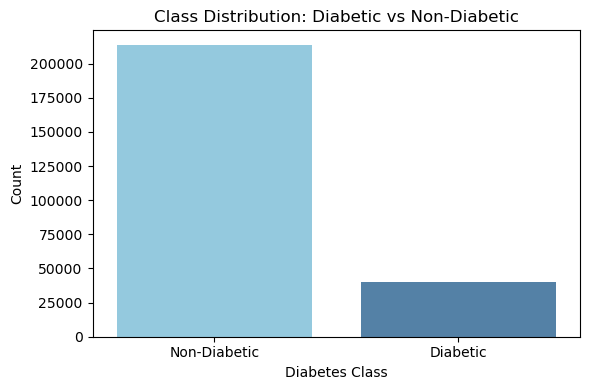

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_encoded, x='Diabetes_Class', palette=['skyblue', 'steelblue'])
plt.title('Class Distribution: Diabetic vs Non-Diabetic')
plt.xlabel('Diabetes Class')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=["Non-Diabetic", "Diabetic"])
plt.tight_layout()
plt.savefig("class_distribution_1.png", dpi=300, bbox_inches='tight')
plt.show()

Having a highly imbalanced dataset can have the following implications:

**Biasness**:
The inability of the model to learn a representation which fits the data. A high bias means a model is not powerful enough to find the patterns in the data, it learns poor representations.
If the dataset is skewed to have one class more than the other, the model gets very good at predicting that one class more than the other.

**Inflated Accuracy**: 

Accuracy alone can be misleading in a highly imbalanced dataset. Accuracy is calculated by taking the sum of (TP+TN)/ALL. It does not consider minority class in it's equation. So, a model can get high accuracy just by predicting the majority class most of the time. 

**Poor Minority Recall**:

Recall is calculated as TP/(TP+FN). In our case, the minority class is the diabetic people. In imbalanced dataset, minority class is less represented which means the model generally fails to detect them. This can result in large FN (a real diabetic model labels as non-diabetic). This then renders the equation to low recall score.

**How to tackle such datasets ?**

- Use Stratified splits- Maintains the proportions of the class
- Use Classification report as a metric- This gives us an entire picture with F1 score, recall and Precision
- Explore PR AUC Curve
- Apply class_weight ='balanced' in classification models wherever possible
- Tune threshold to have a higher recall target
- Use Upsampling technique


Now that the data is pre-processed with some preliminary insights, we will proceed with baseline modelling. Baseline modelling gives us a good starting point to compare advanced models. The parameters are usually kept default and no hyper-parameter tuning is done at this stage.

Since this is a classification task, we will use a **Logistic Regression** model. We will use our encoded dataframe for the modelling.

Splitting the data into features and target

In [5]:
X = df_encoded.drop('Diabetes_Class', axis=1)
y = df_encoded['Diabetes_Class']

X

In [6]:
y

0         0
1         0
2         0
3         0
4         0
         ..
253675    0
253676    1
253677    0
253678    0
253679    1
Name: Diabetes_Class, Length: 253680, dtype: int64

### <a id="stratify-split"></a> Stratify Split

I have decided to split the data into **80% training and 20% testing**.
Since my dataset is imbalanced, I used stratification to ensure that both the training and test sets preserve the original class proportions. This prevents the model from being biased due to class imbalance in either subset.

Using a random_state ensures reproducibility, meaning the split will be the same every time the code is run.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=101
)

### <a id="feature-engineering--standard-scaler"></a> Feature Engineering — Standard Scaler

Machine learning models are senstive to feature inputs. If feature inputs are on different scales such that one scale (unit) dominates the other, the results would be biased.

To avoid that, we need to scale the features to common unit.

**Note: All scaling should be done **after** train/test split to avoid leaking information from your test set into your training data**. 

In [8]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

**StandardScaler()** : initializes the scaler. It doesn't do anything yet — it's just preparing the tool to learn the mean and standard deviation of each feature.

**scaler.fit_transform(X)**:

This does two things:

**fit(X)**: Calculates the mean and standard deviation for each feature in the dataset X.

**transform(X)**: Applies the standardization across the dataset

**X_train/test_scaled**- a new numpy array having all features standardized

### <a id="logistic-regression--normal"></a> Logistic Regression — Normal

In [9]:
# 1. Instantiate model
log_reg = LogisticRegression(max_iter=1000, random_state=101)

# Fit on training data
log_reg.fit(X_train_scaled, y_train)

# 3. Score on the training data
print(f"The training accuracy of the model is {log_reg.score(X_train_scaled, y_train)}")

# 4. Score on the testing data
print(f"The test accuracy of the model is {log_reg.score(X_test_scaled, y_test)}")

The training accuracy of the model is 0.847918637653737
The test accuracy of the model is 0.8491406496373384


Here, I have tried to score the model on both training and test set. Since both gave **high accuracy (84%)** , it signifies a good fit **(no over or under fitting)**. The model has successfully identified the relationship between the features and the target variable.

**model.score()** internally calls **model.predict()** to get predictions and then calculates a default metric based on the model type (e.g., accuracy for classification, R-squared for regression).

Since, our model is not overfitting, there is no need to further optimize the regularization hyperparameter for logisitic regression.

However, it is important to note that **just relying on the accuracy score especially when the data is highly imbalanced can be misleading**. This score could be over representing the class (in this case people with no diabetics) more than cases with people who have diabetes. Thus, we will explore other metrics (below) and gather insights.

#### <a id="classification-report--normal"></a> Classification Report — Normal

Even though .score() gives accuracy, it does not work well for our imbalanced data set (our case). We will explore classification report:

**Precision**- How often the prediction is correct? In other words, of all people the model said are diabetic, how many were actually diabetic??

Precision measures what proportion of a model assigned to positive are actually members of the positive class

**Recall**- Out of all the actual cases, how many classes were identified properly? In other words, of all actual diabetic people, how many did the model correctly catch?

Recall measures how many members of the positive class the model correctly identified out of the total positives

**F1 score**- Harmony mean of the model- Balance of Precision & Recall

**Classification_report** gives us a complete picture about precision, recall, and  𝐹1 score for both the positive class and also the negative class

In [10]:
# Remember the goal of the project

From a **healthcare industry** perspective, the most important evaluation metric should be **Recall**. Our goal is to build a model which detects diabetic patients from a health survey data. The model should be able to flag people who are likely diabetic so they can get further tests or care. Although not ideal, we can sacrifice precision because even if healthy people are incorrectly diagnosed, they can take further tests and be cleared. Classification report helps us get a clear picture of precision, recall and F1 score.

In [11]:
# Evaluation on Test Set
y_test_pred = log_reg.predict(X_test_scaled) 

#log_reg is our trained log regression model which was trained on our training dataset.
# Using the same model, we are trying to predict the labels based on the X_test_scaled (our test features after scaling)
# Predictions are made with a threshold of 0.5 and stored in this array (y-test_pred)

**log_reg.predict**: Helps us to get predicted class label for each test sample. We need this to generate the confusion matrix and generate the classification report

In [12]:
# Classification Report
print("Classification Report for Logistic Regression-Normal:\n", classification_report(y_test, y_test_pred)) #comparing true labels for each samples vs labels my model predicted for those same samples


Classification Report for Logistic Regression-Normal:
               precision    recall  f1-score   support

           0       0.86      0.97      0.92     42741
           1       0.57      0.18      0.27      7995

    accuracy                           0.85     50736
   macro avg       0.72      0.58      0.60     50736
weighted avg       0.82      0.85      0.81     50736



**Observations**

**Class 0**: Represents cases where people do not have diabetes. It can be seen that both **precision (0.85) and recall (0.97)** are very high and the model is able to accurately predict the right class and identify patients with no diabetes.

**Class 1**: Represents cases where people are diabetic. Both **precision (0.56) and recall (0.18)** are very low. **Low recall means that the model misses a lot of actual diabetics. Low precision means a lot of patients were diagnosed incorrectly as diabetic**.

Since, as it was mentioned earlier, the main evaluation metric is recall. Having such low recall for one of the classes means the model is not efficient and must be improved.

**There is no point and going to check for other evaluation metric when the main criteria of recall has failed**.

Thus, I will be directly exploring **balanced** & **upsampling** technique.

### <a id="logistic-regression--balanced"></a> Logistic Regression — Balanced

In [13]:
# 1. Instantiate model

# 'class_weight=balanced' gives each class weight inversely proportional to its TRAIN frequency

log_reg = LogisticRegression(max_iter=1000, random_state=101,class_weight='balanced') #balanced introduced here

# Fit on training data
log_reg.fit(X_train_scaled, y_train)

# 3. Score on the training data
print(f"The training accuracy of the model is {log_reg.score(X_train_scaled, y_train)}")

# 4. Score on the testing data
print(f"The test accuracy of the model is {log_reg.score(X_test_scaled, y_test)}")

The training accuracy of the model is 0.7261412015137181
The test accuracy of the model is 0.7297185430463576


In [14]:
# Evaluation on Test Set
y_test_pred = log_reg.predict(X_test_scaled)  #confusion matrix and classification report

#### <a id="classification-report--balanced"></a> Classification Report — Balanced


In [15]:
# Classification Report
print("Classification Report for Logistic Regression-Balanced:\n", classification_report(y_test, y_test_pred))

Classification Report for Logistic Regression-Balanced:
               precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.65     50736
weighted avg       0.85      0.73      0.76     50736



The accuracy scores went down from **83 % to 72 %**

**Class 0**: It can be seen that precision (0.94) has improved but recall (0.72) has reduced. Not the most ideal situation

**Class 1**: Precision (0.34) has reduced but recall (0.77) has significantly improved. 

This means that **class weight= balanced has improved our overall model performance** as per the goal but in the process we sacrificed some precision.

### <a id="logistic-regression--upsampling"></a> Logistic Regression — Upsampling


To potentially improve our model, we can "upsample" the minority class. This entails us resampling the observations that belong to the under-represented class so that our training data consists of equal proportions of each class.

A very important note here is that it should be done only to the **training data**. The test data should remain untouched and have class imbalance consistent with what you would expect the real world to be

In [16]:
# Split the data again
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=101
)

In [17]:
# Upsample (only X_train, y_train)

# we are trying to duplicate minority class (Class 1: Diabetic) samples in the training set to balance it with the majority class (Class 0: Non-Diabetic)

# Show number of diabetic (1) samples before upsampling

print("Number of class 1 (diabetic) examples before:", X_train[y_train == 1].shape[0])   #shape[0] gives the number of rows

X_pos = X_train[y_train == 1] # pulls out only the positive cases where diabetes is 1 from training set. This is the minority class we want to duplicate

y_pos = y_train[y_train == 1] # corresponding target values which will all be 1

# make copies of positive cases until they match the number of negative cases
X_dup, y_dup = resample(
    
    X_pos, 
    
    y_pos, 
    
    replace=True, # same row can be picked more than once; needed when we dont have enough unique diabetic rows
    
    n_samples=X_train[y_train == 0].shape[0], # gets the target number of samples to match the number of non-diabetic patients in training data
    
    random_state=17  #for reproducibility
)

print("Number of class 1 (diabetic) examples after:", X_dup.shape[0])    #after duplication how many diabetic samples

# Combine majority class (0) with upsampled minority class (1)

X_train_upsampled = np.vstack((X_train[y_train == 0], X_dup)) #Stacking 2 arrays including non-dibaetic and upsampled diabetic, thus making a new training set

y_train_upsampled = np.hstack((y_train[y_train == 0], y_dup)) #stacks the target values for both diabetic and non-diabetic

# convert to DataFrame

X_train_upsampled = pd.DataFrame(X_train_upsampled, columns=X_train.columns) #converts to dataframe and keeps the original column names

Number of class 1 (diabetic) examples before: 31982
Number of class 1 (diabetic) examples after: 170962


The minority class representation improved **significantly**

In [18]:
from collections import Counter
print("Orig train:", Counter(y_train))
print("Upsampled :", Counter(y_train_upsampled))  # should be equal counts

# Sanity: make sure you’re actually using the upsampled data
X_fit, y_fit = X_train_upsampled, y_train_upsampled   # <- use these to fit

Orig train: Counter({0: 170962, 1: 31982})
Upsampled : Counter({0: 170962, 1: 170962})


In [19]:
counts = Counter(y_train_upsampled)
print("Class distribution after upsampling:", counts)
print("Total rows after upsampling:", sum(counts.values()))

Class distribution after upsampling: Counter({0: 170962, 1: 170962})
Total rows after upsampling: 341924


Now that the data is upsampled, let's scale the data.

In [20]:
#scale the dataframe after upsampling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_upsampled)
X_test_scaled = scaler.transform(X_test)  # use original test set

In [21]:
model = LogisticRegression(max_iter=1000, random_state=101)
model.fit(X_train_scaled, y_train_upsampled)

LogisticRegression(max_iter=1000, random_state=101)

#### <a id="classification-report--upsampling"></a> Classification Report — Upsampling

In [22]:
# Predict on the scaled test set by using our trained logistic regression model
y_test_pred = model.predict(X_test_scaled)  

# Predict probabilities for each test sample (useful for ROC AUC)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
train_accuracy = model.score(X_train_scaled, y_train_upsampled)
test_accuracy = model.score(X_test_scaled, y_test)

print("Training Accuracy:", round(train_accuracy * 100, 2), "%")
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

# Classification Report
print("\n Classification Report for Logistic Regression-Upsampling:\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy: 74.24 %
Test Accuracy: 72.9 %

 Classification Report for Logistic Regression-Upsampling:

              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736



**Observations**


The accuracy scores increased to **aprrox. 74 %**. This score is acceptable for a baseline model. 

The class precision and recall remain same as the class weighted model.

The similarity in results suggests that for this dataset and model, either method is equally effective. In deployment, class weighting may be preferred for efficiency, while upsampling remains an option for algorithms that lack class weight support.


### <a id="advanced-evaluation-metrics--confusion-matrix--rocpr-curves"></a> Advanced Evaluation Metrics — Confusion Matrix & ROC/PR Curves

We can use other evaluation metrics from our tool kit and gather more insights.

**Confusion Matrix** gives us a better understanding where misclassifications occur. 

**Reciever Operator Characteristic (ROC) AUC curve**: The ROC is a graphical measure which compares the true positive and false positive rates of a binary model. The AUC curve provides a measure of model's quality. The AUC is advantageous as a performance metric because it captures both the performance in the negative and positive class unlike the F1 score. It also is unique in that it does not change depending on the probability threshold, because it is calculated looking at all of the thresholds. Eventually, it helps us adjust the model in order to strike the correct balance

**Precision-Recall Curve**: This curve is more suited for imbalanced database. As the name suggest, this model gives the curve between precisio and recall. This curve puts spotlight on how well a model finds actual positives without being influced by majority class.

**Confusion Matrix**

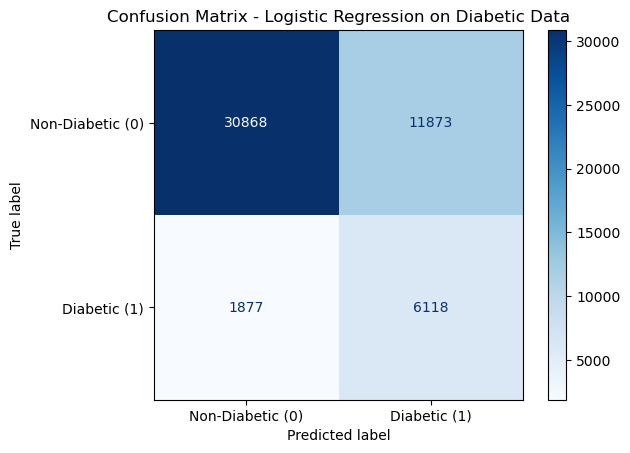

In [23]:
# y_test: true labels
# y_pred: predictions from logistic regression
cm = confusion_matrix(y_test, y_test_pred) 

# Display it nicely

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic (0)", "Diabetic (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression on Diabetic Data")
plt.savefig("Confusion LR.png", dpi=300, bbox_inches='tight')
plt.show()


**True Negatives (TN): 30,868**

- These are non-diabetic correctly predicted as non-diabetic

**False Positives (FP): 11,873**

- These were actually negative, but the model mistakenly labeled them positive.

In this context: non diabetics that were incorrectly flagged as diabetic

**False Negatives (FN): 1,877**

- These were actually positive, but the model predicted them as negative.

So diabetic cases that the model missed.

**True Positives (TP): 6,118**

- Diabetic correctly predicted as Diabetic.
    
The model now has better balance between sensitivity (recall) and specificity, which is crucial in healthcare models.

**(ROC) AUC curve**

In [24]:
# Building an ROC AUC Curve

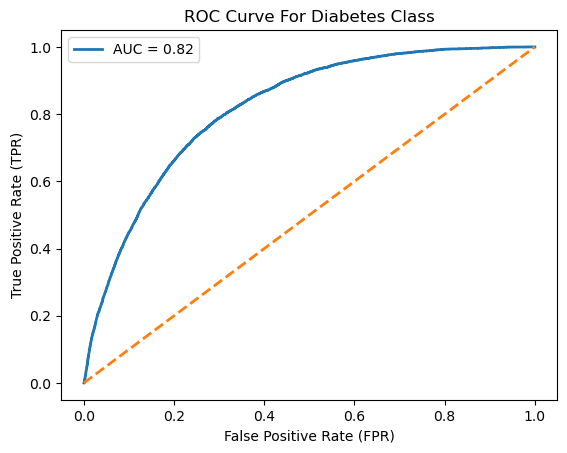

Area under curve (AUC):0.8184511844902479



In [25]:
fp_rate, tp_rate, thresholds = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure()

plt.plot(fp_rate, tp_rate, lw=2, label="AUC = %0.2f" % roc_auc)#  x is FPR and y is TPR
plt.plot([0, 1], [0, 1], lw=2, linestyle="--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve For Diabetes Class")
plt.legend(loc="best")
plt.savefig("ROC_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Area under curve (AUC):{roc_auc}")
print()

**Observations**

Here we are plotting between the False Positive Rate (FPR), True Positive Rate (TPR) at various classification thresholds. A curve closer to the top left corner indicates a better model as it achieves a high recall with low false positive rate. 

Our curve being well above the diagonal (random guessing) line means the model is significantly better than random classification

**TPR**: Ability to catch diabetics

**FPR**: wrongly labeling non-diabetics as diabetics

**y_test**: true labels

**y_proba**: predicted probabilities for class 1 (diabetic)

**roc_auc = roc_auc_score(y_test, y_proba)**: calculates the Area Under the ROC Curve (AUC), which quantifies model performance

An AUC of 0.818 means that there is an **81.8% chance that the model will correctly distinguish a randomly chosen diabetic patient from a non-diabetic patient**.

The dash line represents random guessing and our curve is well above that which is good. ROC is threshold-independent, so it gives a more complete picture of model performance than accuracy.


**However, since our data set is highly imbalanced, ROC AUC curve considers true negatives in its calculation. In our case, we have lot of true negatives (26,823) which can skew our results. So even if the ROC-AUC score looks high,  the models may still not be very good at finding the true positives**

For this reason, we rely on another metric called **PR Curve** which primarly focuses only on the positve class and ignores the true negatives

**PR Curve**

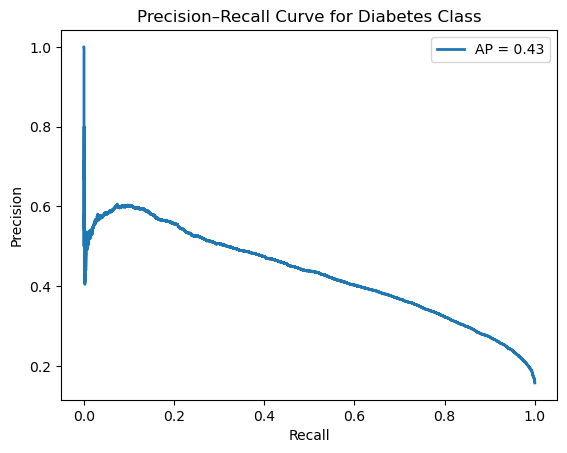

Average Precision (AP): 0.43


In [26]:
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
avg_precision = average_precision_score(y_test, y_test_proba)

# Plot PR Curve
plt.figure()
plt.plot(recall, precision, lw=2, label='AP = %0.2f' % avg_precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve for Diabetes Class')
plt.legend(loc="best")
plt.savefig("PC_Curve.png", dpi=300, bbox_inches='tight')
plt.show()

# Print Average Precision Score
print(f"Average Precision (AP): {avg_precision:.2f}")

**Observations**

Average Precision (AP) = 0.43. This is the area under the PR Curve. It means that whenever our model predicts 'diabetic', it is correct 43 % of the time across all recall levels.

In imbalanced dataset this curve is more representative as it primarly focuses on the positive class. 

The curve starts high on the left (high precision, low recall)- meaning if we have very strict threshold, we will get fewer predictions but more accuracy.
As recall increases, precision drops, meaning to catch more diabetics, we have to accept (sacrific) more false positives.
Smooth decline shows the trade of between catching all positive cases and keeping predictions accurate.

In advanced modelling, I will explore how I can manage the balance between precision and recall to get better results.

### <a id="summary-of-baseline-logistic-models-class-1--diabetic"></a> Summary of Baseline Logistic Models (Class 1 — Diabetic)

| Method                       | Train Accuracy | Test Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | Key Observation |
|------------------------------|----------------|---------------|---------------------|------------------|--------------------|-----------------|
| **Baseline (No Balancing)**  | ~84%           | ~84%          | ~0.65               | ~0.18            | ~0.28              | Very high accuracy due to class imbalance; fails to identify most diabetics (low recall). |
| **Class Weight = 'balanced'**| ~72%           | ~72%          | 0.34                | 0.77             | 0.47               | Recall for diabetics improved drastically (~4× higher); accuracy dropped due to better focus on minority class. |
| **Upsampling (Minority Class)** | ~74%        | ~73%          | 0.34                | 0.77             | 0.47               | Very similar to class_weight results; recall gain same as 'balanced', but accuracy slightly higher than balanced on training & test. |



### <a id="logistic-regression--upsample-odds-ratio-interpretation"></a> Logistic Regression — Upsample Odds Ratio Interpretation

In Logistic Regression, we can understand the relationship of various features with respect to our target model by taking out the odds ratio of those features.


In [27]:
# Extracting the coefficients
# Get feature names
feature_names = X_train.columns   # we need these features as a input to take out the odds ratio

# Get coefficients
coef = model.coef_[0] # the coefficients are stored in the 0 index and it is this value's exponent which gives us the Odds ratio

# Create dataframe
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef,
    "Odds Ratio": np.exp(coef)   # converting log-odds to odds ratio
}).sort_values(by="Odds Ratio", ascending=False)

coef_df.head(10)  # Top 10 features

,Feature,Coefficient,Odds Ratio
22,General_Health_4,0.683390,1.980580
21,General_Health_3,0.619214,1.857468
3,BMI,0.514004,1.671972
23,General_Health_5,0.500520,1.649579
17,Age_Group,0.420691,1.523013
0,HighBP,0.345191,1.412259
1,HighChol,0.298372,1.347663
20,General_Health_2,0.298331,1.347607
2,CholCheck,0.187618,1.206373
16,Sex,0.128596,1.137231


For interpretation purposes, it is important to take out the coefficients and see how each features impact diabetes. However, the coefficeints alone are difficult to interpret, so it is essential to find the **odds ratio** to establish meaninful relations.

- **Odds Ratio > 1:** The feature increases the odds of diabetes.  
- **Odds Ratio < 1:** The feature decreases the odds of diabetes.  
- **Odds Ratio = 1:** No effect on diabetes odds.

**Note that for General Health- When one hot encoding was done, Excellent (General Health 1) was chosen as the reference group. Similarly, for sex, 0 (female) is used as reference group automatically by the model**

In [28]:
# Summary of Interpretation

| **Factor**              | **Odds Ratio**      | **Interpretation**                                                                   |
| ----------------------- | ------------------- | ------------------------------------------------------------------------------------ |
| General Health (Fair)   | **1.98**            | Nearly **2x more likely** to have diabetes vs. excellent health.                     |
| General Health (Good)   | **1.85**            | \~**85% higher odds** compared to the healthiest group.                              |
| BMI                     | **1.67**            | Each unit increase (scaled) raises odds by **67%**.                                  |
| General Health (Poor)   | **1.64**            | Strongly associated with higher diabetes likelihood.                                 |
| Age Group (Older)       | **1.52**            | Older adults have **52% higher odds** than the youngest group.                       |
| High Blood Pressure     | **1.41**            | Increases risk by **41%**.                                                           |
| High Cholesterol        | **1.34**            | Moderately increases diabetes risk.                                                  |
| Cholesterol Check (Yes) | **1.20**            | \~**20% higher odds** (likely because at-risk people are more likely to get tested). |
| Sex (Male)              | **1.13**            | Males have **13% higher odds** compared to females.                                  |



**Possible Explainations**

Although we might expect 'Poor' health to have the highest risk, in this dataset 'Fair' shows the strongest association. The model is actually following the order: **Fair (highest risk of diabetes) > Good > Poor > 
Excellent**. Possible Explainations for this could be:

- People might not rate themselves consistently. Meaning, even if someone has diabetes, they might still call their health 'fair' rather than 'poor'
- Sample size imbalance have skewed those observations. Looking at the dataset, only fraction of people have called themselves 'poor'. This means the model has lost its statistical power.
- Also, it is important to remember the model is not saying that poor health is less likely to cause diabetes, it is just say saying that the model shows other cateogries having stronger assoication to diabetes.

Males have **~13% higher odds of diabetes compared to females**. Possible explainations for this could be:

- Men tend to have more visceral fat (around the abdomen), which is strongly linked to insulin resistance and diabetes.
- As men age, the testosterone levels decrease and that is attributed to higher insulin resitance.

BMI increases relates to higher diabetes because it leads to obesity and medical studies have shown obesity to be the gateway for this disease.

People with age have higher chances of diabetes because as the body becomes older, their muscle mass reduces and fat mass increases. This can lead to insulin resistance

High BP reduces the ability for blood to circulate around the body. This direct impacts the insulin delivery for cells to use and leads to higher blood sugar levels

High Cholestrol is known to be medically linked with diabetes and thus this trend makes sense

CholCheck is a measure to find if someone is having diabetes or not. So people who typical get themselves checked, will have higher chances of finding out if they have the disease

## <a id="helper-utilities"></a> 2) Helper Utilities

### <a id="model-runner--metrics-helper"></a> Model Runner & Metrics Helper

In [29]:
"""
This is a class function which helps us to minimize code and helps us to pass parameters to plot different evaluation metrics
We will use it for Decision Tree, Random Forest, KNN and XGBoost.
X_tr = training feature (inputs)
y_tr = taining labels (inputs)
X_te = test features
y_te = test labels
"""
SEED = 101  # keep reproducible

def fit_and_eval(model, model_name, X_tr, y_tr, X_te, y_te):
    """Fit a model and print key metrics focused on class 1 (positive)."""
    model.fit(X_tr, y_tr)

    # proba for metrics that need scores (AUCs). Trees all support predict_proba
    y_proba = model.predict_proba(X_te)[:, 1] # Scores/probabilities for class 1 (needed for AUC metrics)
    y_pred  = model.predict(X_te)   # Hard predictions at threshold = 0.50 (can be changed after threshold tuning) 

    print(f"\n=== {model_name} on Train ===")
    print(confusion_matrix(y_te, y_pred))
    print(classification_report(y_te, y_pred, digits=2))
    print("ROC AUC:", roc_auc_score(y_te, y_proba))
    print("PR  AUC:", average_precision_score(y_te, y_proba))

## <a id="baseline-model--decision-tree"></a> 3) Baseline Model — Decision Tree


A decision tree is a supervised learning algorithm that uses a tree-like structure to make predictions.
It takes input data, splits it based on features to create branches, and assigns class labels to the leaf nodes. 
Essentially, it creates a flowchart of questions that lead to a category prediction. It's used for both classification and regression task

Decision Trees work by iteratively finding the **best splits** to make in the data. This results in a tree of "decisions" that can be used for prediction and inference.

In [30]:
"""
Decision Tree (imbalanced baseline)

- class_weight='balanced': weight classes inversely to their frequency
  (similar effect to random upsampling without duplicating rows).

"""
dt = DecisionTreeClassifier(
    random_state=SEED,  
    max_depth=None,      # Default values        
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight = 'balanced'   #account for class imbalance
)

### <a id="evaluation-metrics-for-decision-tree"></a> Evaluation Metrics for Decision Tree

In [31]:
fit_and_eval(dt, "DecisionTree", X_train, y_train, X_test, y_test)  #calling the function


=== DecisionTree on Train ===
[[36989  5752]
 [ 5467  2528]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     42741
           1       0.31      0.32      0.31      7995

    accuracy                           0.78     50736
   macro avg       0.59      0.59      0.59     50736
weighted avg       0.78      0.78      0.78     50736

ROC AUC: 0.5910098478613545
PR  AUC: 0.2094155983278001


**Observations**


The accuracy scores is **approx. 78 %**. This score is acceptable for a baseline model. 

**Class 0**: Represents cases where people do not have diabetes. It can be seen that both **precision (0.87) and recall (0.87)** are very high and the model is able to accurately predict the right class and identify patients with no diabetes.

**Class 1**: Represents cases where people are diabetic. Both **precision (0.31) and recall (0.32)** are very low. **Low recall means that the model misses a lot of actual diabetics. Low precision means a lot of patients were diagnosed incorrectly as diabetic**.

Since, as it was mentioned earlier, the main evaluation metric is recall. Having such low recall for one of the classes means the model is not efficient and must be improved.

The FP were around 5752 (non-diabetic flagged as diabetic) and FN were around 5467 (diabetes missed)


### <a id="decision-tree--upsampled"></a> Decision Tree — Upsampled

In [32]:
dt = DecisionTreeClassifier(
    random_state=SEED,
    max_depth=None,              
    min_samples_split=2,
    min_samples_leaf=1
)
fit_and_eval(dt, "DecisionTree", X_train_upsampled, y_train_upsampled, X_test, y_test)


=== DecisionTree on Train ===
[[36985  5756]
 [ 5460  2535]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87     42741
           1       0.31      0.32      0.31      7995

    accuracy                           0.78     50736
   macro avg       0.59      0.59      0.59     50736
weighted avg       0.78      0.78      0.78     50736

ROC AUC: 0.5909009279228427
PR  AUC: 0.20876593130655274


The accuracy score is around 78%.
The recall and precision did not change at all from upsampling. PR curve is 0.2 and ROC is 0.59 same as above. 

## <a id="baseline-model--random-forest"></a> 4) Baseline Model — Random Forest


A Random Forest is a machine learning method that works by creating many individual decision trees during training and combining their results to produce a more accurate prediction than a single tree.

A Random Forest works by fitting several deep decision trees. Each tree is fitted to a random subset of the data and features. The trees are trained in parallel and their decisions are totally independent of each other. The only thing we can control for is the depth of the trees and number of trees we fit.

In [33]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,   #Selecting some random values for baseline
    max_depth=None,              
    n_jobs=-1,   #makes sure all CPU core are computing
    random_state=SEED,   # ensure randomness
    class_weight="balanced_subsample"  #to handle class imbalance
) 

### <a id="evaluation-metrics-for-random-forest"></a> Evaluation Metrics for Random Forest

In [34]:
fit_and_eval(rf, "Random Forest", X_train, y_train, X_test, y_test)


=== Random Forest on Train ===
[[41142  1599]
 [ 6496  1499]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91     42741
           1       0.48      0.19      0.27      7995

    accuracy                           0.84     50736
   macro avg       0.67      0.58      0.59     50736
weighted avg       0.80      0.84      0.81     50736

ROC AUC: 0.7929035585122362
PR  AUC: 0.3877813863083388


The accuracy score is around 84 % which is better than DT.
The recall is 0.19 & and precision is 0.48 for class 1. The precision improved from DT but recall decreased. This could be due to that fact that Random forest was more conservative with default threshold of 0.5 in its algorithm. DT could also be overfitting to get higher recall.

PR curve is 0.38 and ROC is 0.79 which is way better than DT.

### <a id="random-forest--upsampled"></a> Random Forest — Upsampled

In [35]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,              # again, feel free to try 8, 12, etc.
    n_jobs=-1,
    random_state=SEED
)
fit_and_eval(rf, "RandomForest", X_train_upsampled, y_train_upsampled, X_test, y_test)


=== RandomForest on Train ===
[[39150  3591]
 [ 5220  2775]]
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     42741
           1       0.44      0.35      0.39      7995

    accuracy                           0.83     50736
   macro avg       0.66      0.63      0.64     50736
weighted avg       0.81      0.83      0.82     50736

ROC AUC: 0.7903788250942209
PR  AUC: 0.36826413184436146


The accuracy score is around 83 % which is better than DT.

The recall is 0.35 & and precision is 0.44 for class 1. The precision improved from DT but recall decreased. This could be due to that fact that Random forest was more conservative with default threshold of 0.5 in its algorithm & DT could also be overfitting to get higher recall.

PR curve is 0.37 and ROC is 0.79 which is way better than DT.

## <a id="baseline-model--knn"></a> 5) Baseline Model — KNN

K-Nearest Neighbors (kNN) is one of the simplest, yet powerful, **non-linear models**. kNN uses the notion of **similarity** and **distance** to find points similar to those we want to predict and assign a label to them based on those points. Unlike linear models, KNN makes no assumptions on the distribution of the data, and as such it can find much more complex relationships.

In [36]:
# We are trying another technique to do ML modelling and that is to build a pipeline and do all the steps in one shot

### <a id="knn-via-pipeline"></a> KNN via Pipeline

In [37]:
from sklearn.pipeline import Pipeline

In [38]:
# I am creating a pipeline using its function and then passing parameters as to what I want it to do. Initially I want the x test and train to be scaled, then Invoke KNN function with some default values 
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, n_jobs =-1,weights="distance")) # All points in each neighborhood are weighted equally
])

knn_pipe.fit(X_train, y_train)  #fitting those train values

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_jobs=-1, weights='distance'))])

### <a id="evaluation-metrics-for-knn"></a> Evaluation Metrics for KNN

In [39]:
fit_and_eval(rf, "KNN", X_train, y_train, X_test, y_test)


=== KNN on Train ===
[[41186  1555]
 [ 6375  1620]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     42741
           1       0.51      0.20      0.29      7995

    accuracy                           0.84     50736
   macro avg       0.69      0.58      0.60     50736
weighted avg       0.81      0.84      0.81     50736

ROC AUC: 0.7959951265720389
PR  AUC: 0.4006093689689143


The average score was approx 84 % . The class 1 precision was 0.51 and recall was 0.2. The number of false positives were 1555 & false negatives were 6375.

ROC curve was around 79 % and PR was around 40 %.


### <a id="knn--upsampled"></a> KNN — Upsampled

In [64]:
# I have code commented below to save computing time

In [40]:
# knn = KNeighborsClassifier(
#     n_neighbors=5,        # Default values
#     weights="distance",   # usually better with imbalance
#     n_jobs=-1
# )

In [41]:
# fit_and_eval(knn, "KNN (upsampled train)", X_train_upsampled, y_train_upsampled, X_test, y_test)

The average score was approx 70 % which went down for this mode. The class 1 precision was 0.3 and recall was 0.6. The number of false positives were 11548 & false negatives were 3310.

ROC curve was around 70 % and PR was around 30 %

When we upsampled KNN, we lost precision but improved recall. This could be due to the fact that upsampling floods each neighborhood with duplicated positives, so KNN votes 1 more often which increases it's recall.

Random forest might have lower recall, but its precision is higher, so when it does flag somebody for diabetes, its more oftern right. The ensemble learns better splits and ranks cases better.

## <a id="summary-of-all-baseline-models"></a> 6) Summary of All Baseline Models

### <a id="baseline-comparison-class-1-focus"></a> Baseline Comparison (Class 1 Focus)

| Model                   | Train Type | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Insights                                                        |
| ----------------------- | ---------- | ------------------- | ---------------- | ------------ | --------------------------------------------------------------- |
| **Logistic Regression** | Original   | **0.57 🏆**         | 0.18             | 0.27         | Highest precision, but terrible recall → misses most diabetics. |
| **Logistic Regression** | Balanced   | 0.34                | **0.77 🏆**      | **0.47 🏆**  | Huge recall boost, best F1. Best choice for medical settings.   |
| **Logistic Regression** | Upsampled  | 0.34                | **0.77 🏆**      | **0.47 🏆**  | Same as balanced weights → consistent improvement.              |
| **Decision Tree**       | Original   | 0.31                | 0.32             | 0.31         | Weak overall, poor precision/recall.                            |
| **Decision Tree**       | Upsampled  | 0.31                | 0.32             | 0.31         | Almost identical to original → upsampling doesn’t help DT much. |
| **Random Forest**       | Original   | 0.48                | 0.19             | 0.27         | Precision okay, recall very poor → misses diabetics.            |
| **Random Forest**       | Upsampled  | 0.44                | 0.35             | 0.39         | Best of the tree-based models → recall improved with modest F1. |
| **KNN**                 | Original   | 0.51                | 0.20             | 0.29         | Decent precision, weak recall.                                  |
| **KNN**                 | Upsampled  | 0.29                | 0.59             | 0.39         | Big recall boost, but precision drops a lot.                    |


**Interpretation**

To establish a fair starting point, multiple baseline models were evaluated on the encoded diabetes dataset. The primary focus was Recall for Class 1 (Diabetic cases), since in a medical context, missing a diabetic patient is more costly than a false alarm. Each baseline model was also compared to its upsampled version.

**Key Insights**

- Logistic Regression- Upsampled & Balanced are the clear winners with highest recall of 77 % whilst compromising on the precision at 34 % and overall F1 score of 0.47. Since both give same results, *I will pick the upsampled model for my advanced tuning*.
- Other modelling classifiers like Random Forest, DT, KNN struggled to get a higher recall. This can be expected because tree-based models tend to prioritize  the majority class to maximize accuracy. Distance based classifier also struggles because the majority class dominates near neighbours, so minority points get misclassified.
- Random forest tajes average of many trees independently and it reduces variance, however, XGBoost builds sequentially from the residual errors of each tree. Therefore, it performs better
- DT is prone to overfitting and can have high variance. Meaning, even a slight change in the model, can have severed effects. However, it is very interpretable
- KNN is distance based learning. However, it cannot handle class imbalance well and is a lazy learner. KNN upsampled has increased recall because it packs more positive into neighbourhood.
- KNN are hypersensitive to scaling and suffer from curse of dimensionality which means after one-hot encoding, the distances gets less meaningful-noisy neighbours



## <a id="advanced-modelling"></a> 7) Advanced Modelling

We will use Log regression as our advanced model to tune. Just to ensure nothing has changed from earlier and also to make quick use of pipeline, let us train the model again.

In [42]:
# Let us re-train our baseline model with pipeline method just to ensure all are set well

SEED = 101
logreg_pipe = Pipeline(steps=[
        ("scale", StandardScaler(with_mean=False)), # with_mean=False keeps it compatible with sparse inputs
        ("clf", LogisticRegression(
        max_iter=1000,  #allows enough iterations for solver to converge
        class_weight="balanced",  #imbalanced data handling
        random_state=SEED  #makes the solver random for repeatability
    ))
])

logreg_pipe.fit(X_train, y_train)  #fitting those train values

Pipeline(steps=[('scale', StandardScaler(with_mean=False)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=101))])

In [43]:
fit_and_eval(logreg_pipe, "Log regresion pipeline)", X_train, y_train, X_test, y_test)


=== Log regresion pipeline) on Train ===
[[30904 11837]
 [ 1876  6119]]
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.65     50736
weighted avg       0.85      0.73      0.76     50736

ROC AUC: 0.8184618542223996
PR  AUC: 0.4312619682439769


<a id="hyperparameter-tuning-for-logistic-regression"></a>
### Hyperparameter Tuning for Logistic Regression

In [44]:
# Let us take a subsample of the entire dataset for faster processing time.

In [45]:
SEED = 101
FRAC = 0.50  # use 50% of the training set for a fast search

X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train,
    train_size=FRAC,
    stratify=y_train,      # preserves class ratio in the subset
    random_state=SEED
)

print(X_train.shape, "→ subsample:", X_sub.shape)

(202944, 24) → subsample: (101472, 24)


In [46]:
# building another pipeline to get hypertuned parameters for log regression
pipe_lr = Pipeline([
    ("scale", StandardScaler(with_mean=False)),  
    ("clf", LogisticRegression(max_iter=4000, random_state=SEED))
])

In [47]:
from sklearn.metrics import make_scorer
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

# Keep the grid small & valid to avoid hours of fitting

weight_grid = ["balanced", {0:1.0, 1:2.0}, {0:1.0, 1:3.0}]   # minority class gets bigger weight with balanced

# {0:1.0, 1:2.0} and {0:1.0, 1:3.0} are manual settings that make errors on class 1 2× or 3× as costly as class 0. This pushes the model toward higher recall for class 1 at the expense of precision
# Due to this we dont need to do upsampling as the minority class is being taken care here

# C = inverse of regularization strength (smaller C => stronger regularization)
# clf is a way to say to the model to look inside the step named clf (classifier) and tune those parameters
# Now we will explore different combinations
param_grid = [
    {   # lbfgs supports only L2
        "clf__solver": ["lbfgs"],
        "clf__penalty": ["l2"],
        "clf__C": [0.25, 0.5, 1.0, 2.0],  #different regularization strengths range
        "clf__class_weight": weight_grid
    },
    {   # liblinear supports L1 or L2
        "clf__solver": ["liblinear"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.25, 0.5, 1.0, 2.0],
        "clf__class_weight": weight_grid
    },
    {   # saga supports L1 or L2 
        "clf__solver": ["saga"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.25, 0.5, 1.0, 2.0],
        "clf__class_weight": weight_grid
    },
]

# StratifiedKFold preserves class ratios in each fold (important for imbalance)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)  # 5-fold for speed, shuffle randomizes the order of samples within each class before splitting into folds.
# Optimize for recall on the positive (minority) class
recall_pos = make_scorer(recall_score, pos_label=1)                 

In [48]:
gs_sub = GridSearchCV(  # tries every hyperparameter combo that we had listed in param_grid and evaluates each using cross-validation
    estimator=pipe_lr,  # the model we are using
    param_grid=param_grid,
    scoring=recall_pos, # metric to maximize on the folds
    cv=cv5,  #cross-validation splitter used
    n_jobs=-1, #all CPU cores working in parallel
    verbose=1,  #prints progress message 
    refit=True   # refits the best pipeline on the subsample automatically
)
gs_sub.fit(X_sub, y_sub)  # runs the wholse search on the subsample using CV procedure

print("Best params (subsample):", gs_sub.best_params_)  # gets us the best parameters
print("Best CV recall (class 1):", gs_sub.best_score_)  # gets us the best recall

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best params (subsample): {'clf__C': 0.25, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Best CV recall (class 1): 0.7648048629956086


<a id="retraining-the-model-with-best-parameters-LR"></a>
### Retraining the model with best parameters-LR

Now we need to put these parameters on the FULL training set and build the final log reg model.

In [49]:
final_lr = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=SEED))
])
final_lr.set_params(**gs_sub.best_params_)  # use params from your GridSearch/RandomizedSearch
final_lr.fit(X_train, y_train)  #fit it on the training model



Pipeline(steps=[('scale', StandardScaler()),
                ('clf',
                 LogisticRegression(C=0.25, class_weight='balanced',
                                    max_iter=5000, penalty='l1',
                                    random_state=101, solver='saga'))])

we already accounted for class imbalance by using the class_weight='balanced' approach, so we dont need to work on the upsample data

<a id="final-evaluation-for-logistic-regression-hypertuned"></a>
### Final Evaluation for Logistic Regression (Hypertuned)

In [50]:
 fit_and_eval(final_lr, "Hypertuned Logistic Regression", X_train, y_train, X_test, y_test) # we hypertune on the original training set and not the upsampled one


=== Hypertuned Logistic Regression on Train ===
[[30905 11836]
 [ 1877  6118]]
              precision    recall  f1-score   support

           0       0.94      0.72      0.82     42741
           1       0.34      0.77      0.47      7995

    accuracy                           0.73     50736
   macro avg       0.64      0.74      0.64     50736
weighted avg       0.85      0.73      0.76     50736

ROC AUC: 0.8184619624999885
PR  AUC: 0.43125657503285486


**Interpretation**

The recall still remains at 77 % for class 1. The precision is at 34 %. The overall score is 73 %.

FP was 11836 and FN was 1877. This FN number is quite low and means that it can be good for screening purposes.

| Method                   | Train Type   | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Key Observation                                                                                                     |
| ------------------------ | ------------ | ------------------: | ---------------: | -----------: | ------------------------------------------------------------------------------------------------------------------- |
| **Log Reg — Hypertuned** | **Balanced** |            **0.34** |         **0.77** |     **0.47** | Accuracy **0.73**. Recall-first LR performed best among baselines; interpretable with expected precision trade-off. |


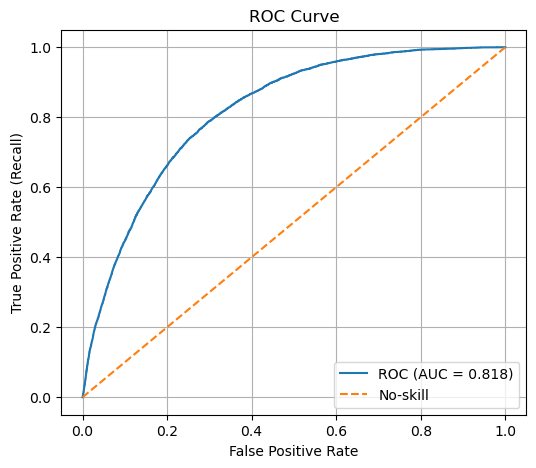

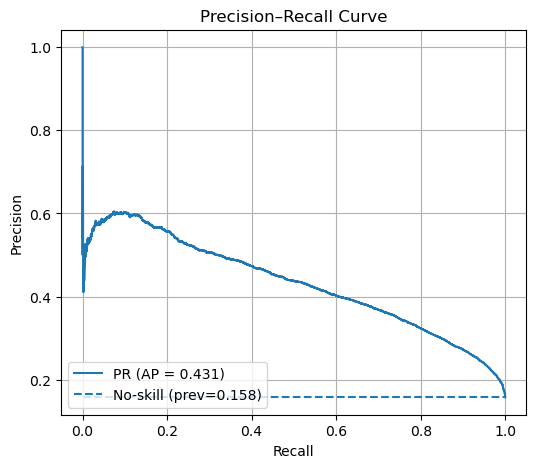

In [51]:
"""
Plot ROC and Precision–Recall curves for a classifier.

- model (pipeline or estimator) is fitted
- X_test, y_test exist

"""

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# 1) Get test-set probabilities for the positive class (class 1)

# Model name is final_lr
y_prob = final_lr.predict_proba(X_test)[:, 1]  #curve requires scores not had labels

# -------------------------
# ROC curve
# -------------------------

# fpr = false positive rate at each threshold
# tpr = true positive rate (recall) at each threshold
# roc_thr = thresholds used to compute (fpr, tpr)

fpr, tpr, roc_thr = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill") #random guess baseline at 0.5 AUC

# mark your tuned threshold if `thr_star` exists
if "thr_star" in locals():
    idx = int(np.argmin(np.abs(roc_thr - thr_star)))
    plt.scatter(fpr[idx], tpr[idx], marker="o", zorder=3, label=f"@ thr={thr_star:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("roc Curve-Log Reg Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()

# -------------------------
# Precision–Recall curve
# -------------------------
# prec, rec computed for a descending set of thresholds
# pr_thr has length len(prec) - 1 by sklearn's definition
# average_precision_score- It summarizes precision across all recall levels, so you don’t have to pick a single threshold first.

prec, rec, pr_thr = precision_recall_curve(y_test, y_prob, pos_label=1)
ap = average_precision_score(y_test, y_prob) # area under PR (Average Precision)
prevalence = y_test.mean()  # Random Guessing line for PR

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR (AP = {ap:.3f})")
plt.hlines(prevalence, xmin=0, xmax=1, linestyles="--", label=f"No-skill (prev={prevalence:.3f})")

# mark the tuned threshold on PR (note: len(pr_thr) = len(prec) - 1)


if "thr_star" in locals():
    idx = int(np.argmin(np.abs(pr_thr - thr_star)))
    plt.scatter(rec[idx], prec[idx], marker="o", zorder=3, label=f"@ thr={thr_star:.3f}")
    
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.savefig("PR Curve-Log Reg Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()

**Observation**

The no-skill line is what you get from random guessing with no predictive power.

ROC (AUC ≈ 0.82): Strong ranking ability—model scores true diabetics higher than non-diabetics ~ 82% of the time. At FPR ≈ 0.2 you can get recall ~0.75–0.8

PR (AP ≈ 0.43, no-skill ≈ 0.16): Good enrichment over baseline; as you push recall up, precision falls (e.g., around recall ~0.77, precision ~0.34).

Takeaway: Model separates classes well and yields meaningfully enriched alerts vs. prevalence.

For screening, pick a lower threshold to hit higher recall (accept more FPs).


**Odds Ratio**

In [68]:
# === Odds Ratios for FINAL tuned Logistic Regression (simple) ===
from sklearn.base import clone

pipe = final_lr  

# 1) Grab the final estimator and its coefficients
#hasattr(pipe, "steps") checks if 'pipe' is a Pipeline; if not, treat it as a plain estimator.


final_est = pipe.steps[-1][1] if hasattr(pipe, "steps") else pipe

#np.asarray(...) ensures we get a real NumPy array (not a nested list)
coef = np.asarray(final_est.coef_).ravel()

# 2) Get feature names that align with those coefficients
#   get_feature_names_out() is a robust way to get post-transformer column names that line up with the LR coefficients.
try:
    feature_names = list(pipe[:-1].get_feature_names_out()) 
except Exception:
    feature_names = list(getattr(pipe, "feature_names_in_", []))

# 3) Build a tidy OR table (OR = exp(coef))
#  We sort by |log(OR)| (i.e., |coef|) to show strongest effects at the top.
or_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coef,
        "odds_ratio": np.exp(coef)
    })
    .assign(effect_size=lambda d: np.abs(np.log(d["odds_ratio"])))
    .sort_values("effect_size", ascending=False)
    .drop(columns="effect_size")
)

# 4) Show top rows
or_df.head(25)


,feature,coef,odds_ratio
21,General_Health_3,0.612940,1.845850
22,General_Health_4,0.588115,1.800591
3,BMI,0.479632,1.615480
17,Age_Group,0.452878,1.572832
23,General_Health_5,0.401248,1.493687
0,HighBP,0.338287,1.402543
20,General_Health_2,0.322113,1.380041
1,HighChol,0.292580,1.339879
2,CholCheck,0.230879,1.259707
10,Heavy_Alcohol_Use,-0.143061,0.866701


<a id="final-logistic-regression--odds-ratios-interpretation"></a>
### Final Logistic Regression — Odds Ratios (Interpretation)


**How to read:**  
- *Odds ratio (OR)* > 1 → higher diabetes odds; OR < 1 → lower odds.  
- For numeric features (e.g., **BMI**), OR is for a **1-SD increase** (because we standardized).  
- For one-hot categories (e.g., **General_Health_3**), OR is **vs the baseline** category.

**Top signals that raise risk (largest ORs):**
- **General_Health_3** ~ **1.85**, **General_Health_4** ~ **1.80**, **General_Health_5** ~ **1.49**  
  → Poorer self-rated health = higher risk.
- **BMI** ~ **1.62**  
  → Higher BMI strongly increases risk.
- **Age_Group** ~ **1.57**  
  → Older groups have higher risk.
- **HighBP** ~ **1.40**, **HighChol** ~ **1.34**, **CholCheck** ~ **1.26**  
  → Blood pressure/cholesterol history and screening are associated with higher detected risk.

**Signals linked with lower risk (OR < 1):**
- **Income** ~ **0.88** (higher income → lower risk signal)
- **Heavy_Alcohol_Use** ~ **0.87** (survey artifact/behavioral confounding likely)

**Mostly neutral in this model (OR ≈ 1):**  
**Smoker**, **Mental_Health**, **AnyHealthcare**, **Stroke** (small effect after other factors).

 **Note:** These are **associations, not causation**. They show which inputs the model leans on most when estimating risk.


<a id="gradient-boosting--xgboost"></a>
## 8) Gradient Boosting — XGBoost

In order to make an even more powerful model, we can try to combine the results of many models. This is the idea of ensemble learning: rather than fitting one model, fit a group (ensemble) of models to produce a single prediction.

Gradient Boosting, which train a sequential collection of models where each model is trained on the errors of the previous one.

Boosting involves making predictions "in series." Each model is trained on the errors of the last model

The Gradient Boosting algorithm fits each sub-model to the residuals of the previous models. It can optimize for various error functions of the residuals.

In [52]:
# === XGBoost (baseline) with automatic preprocessing ===
# Use scale_pos_weight to address class imbalance
# XGBoost does not like any numeric values, so we need to ensure all columns are preprocessed to be categorical
# OneHotEncoder does that job before the model goes through XGBoost

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
SEED = 101

# 1) splits columns by dtype
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns
cat_cols = X_train.select_dtypes(exclude=["number", "bool"]).columns

# 2) Preprocess: OneHot for categoricals, passthrough for numerics
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)
# 3) Class imbalance ratio for XGBoost: scale_pos_weight = (#neg / #pos)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos if pos > 0 else 1.0

# 4) Full pipeline: preprocessing -> XGBClassifier
xgb_baseline = Pipeline([
    ("prep", preprocess),  #transforms X consistently in train/test
    ("xgb", XGBClassifier(
        random_state=SEED,
        tree_method="hist",       # fast, memory efficient histogram grower
        n_estimators=600,         # reasonable default when not using early stopping
        learning_rate=0.05,       # shrinkage
        max_depth=4,              # shallow trees generalize better
        subsample=0.8,            # row sampling
        colsample_bytree=0.8,     # feature sampling
        min_child_weight=1.0,     # default values
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=spw,     # imbalance handling
        eval_metric="logloss"     # threshold-free metrics (AUCs) will be computed downstream
    ))
])

# 5) Evaluate our model
fit_and_eval(xgb_baseline, "XGBoost (baseline)", X_train, y_train, X_test, y_test)



=== XGBoost (baseline) on Train ===
[[30300 12441]
 [ 1712  6283]]
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     42741
           1       0.34      0.79      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.75      0.64     50736
weighted avg       0.85      0.72      0.76     50736

ROC AUC: 0.8254160028628594
PR  AUC: 0.46182264458243977


| Method                 | Train Type   | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Key Observation                                                                                          |
| ---------------------- | ------------ | ------------------: | ---------------: | -----------: | -------------------------------------------------------------------------------------------------------- |
| **XGBoost — Baseline** | **Original** |            **0.34** |         **0.79** |     **0.47** | Accuracy **0.72**. Strong class-1 recall (slightly higher than LR tuned), with expected lower precision. |



**Interpretation**

The results have slightly improved for XGBoost in recall at 0.79 (Log reg was at 0.77). The precision is similar to Log Regr Hypertuned.

The ROC curve is around 0.83 and PR curve is 0.46. 

The reason that XGBoost edges out LR is that it captures non linearities and feature interactions in other wise almost linear dataset better.

<a id="hypertuning-for-xgboost"></a>
### Hypertuning for XGBoost

In [53]:
# === XGBoost (baseline) with automatic preprocessing ===
# Use scale_pos_weight to address class imbalance
# XGBoost does not like any numeric values, so we need to ensure all columns are preprocessed to be categorical
# OneHotEncoder does that job before the model goes through XGBoost

from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

SEED = 101

# 1) splits columns by dtype
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns
cat_cols = X_train.select_dtypes(exclude=["number", "bool"]).columns

# 2) Preprocess: OneHot for categoricals, passthrough for numerics
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)
# 3) Class imbalance ratio for XGBoost: scale_pos_weight = (#neg / #pos)
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos if pos > 0 else 1.0

# 4) Full pipeline: preprocessing -> XGBClassifier
xgb_hypertuned = Pipeline([
    ("prep", preprocess),  #transforms X consistently in train/test
    ("xgb", XGBClassifier(
        random_state=SEED,
        tree_method="hist",       # fast, memory efficient histogram grower
        n_estimators=600,         # reasonable default when not using early stopping
        learning_rate=0.05,       # shrinkage
        max_depth=4,              # shallow trees generalize better
        subsample=0.8,            # row sampling
        colsample_bytree=0.8,     # feature sampling
        min_child_weight=1.0,     # default values
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=spw,     # imbalance handling
        eval_metric="logloss"     # threshold-free metrics (AUCs) will be computed downstream
    ))
])
# 5) Parameter grid to test


param_distributions = {
    "xgb__max_depth":        [3, 4, 5, 6],
    "xgb__learning_rate":    np.linspace(0.03, 0.12, 6).tolist(),   # 0.03..0.12
    "xgb__n_estimators":     [400, 600, 800, 1000],                 # no early stopping during CV
    "xgb__min_child_weight": [1, 2, 5, 10],
    "xgb__subsample":        [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.6, 0.8, 1.0],
    "xgb__reg_lambda":       [0.5, 1.0, 2.0],
    "xgb__reg_alpha":        [0.0, 0.1, 0.5], 
    "xgb__scale_pos_weight": [spw], # keep imbalance fixed to the data ratio
}

# 6) CV & scorer — optimize PR AUC (AKA Average Precision)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pr_scorer = make_scorer(average_precision_score, needs_proba=True)

rs = RandomizedSearchCV(
    estimator=xgb_hypertuned,
    param_distributions=param_distributions,
    n_iter=30,                 
    scoring=pr_scorer,         # PR AUC is better for imbalance
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=SEED,
    refit=True                 # refit best params on the full training set (no early stopping yet)
)

rs.fit(X_train, y_train)
print("Best params (CV):", rs.best_params_)
print("Best CV PR AUC :", round(rs.best_score_, 4))


# 7) Early-stopped final model
# Make a small validation split from training for early stopping.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

# 8) Evaluate our model
fit_and_eval(xgb_hypertuned, "XGBoost (Hypertuned)", X_train, y_train, X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (CV): {'xgb__subsample': 0.7, 'xgb__scale_pos_weight': 5.345569382777812, 'xgb__reg_lambda': 1.0, 'xgb__reg_alpha': 0.5, 'xgb__n_estimators': 400, 'xgb__min_child_weight': 10, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.03, 'xgb__colsample_bytree': 0.8}
Best CV PR AUC : 0.4607

=== XGBoost (Hypertuned) on Train ===
[[30300 12441]
 [ 1712  6283]]
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     42741
           1       0.34      0.79      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.75      0.64     50736
weighted avg       0.85      0.72      0.76     50736

ROC AUC: 0.8254160028628594
PR  AUC: 0.46182264458243977


<a id="retraining-the-model-with-best-parameters"></a>
### Retraining the model with best parameters

In [54]:
"""
Final XGBoost pipeline with best hyperparameters + preprocessing.

- Reuses `preprocess` (ColumnTransformer) so categoricals are one-hot encoded
  and numerics are passed through.
- Injects the best hyperparameters found via RandomizedSearchCV (rs.best_params_)

- Fits once on the full training set and evaluates on test with helper.
"""

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# --- Pull best params from search object ---

best_params = {k.replace("xgb__", ""): v for k, v in rs.best_params_.items()}

# Make sure fixed, safe defaults are present
best_params.update({
    "random_state": SEED,
    "tree_method": "hist",
    "eval_metric": "logloss",
})

# Rebuild the final pipeline: preprocess -> XGBClassifier(best params)
xgb_final = Pipeline([
    ("prep", preprocess),
    ("xgb", XGBClassifier(**best_params))
])

# Fit once on the full training set (no early-stopping here)
xgb_final.fit(X_train, y_train)

# Evaluate using your existing helper
fit_and_eval(xgb_final, "Final XGBoost Hypertuned )", X_train, y_train, X_test, y_test)



=== Final XGBoost Hypertuned ) on Train ===
[[30319 12422]
 [ 1697  6298]]
              precision    recall  f1-score   support

           0       0.95      0.71      0.81     42741
           1       0.34      0.79      0.47      7995

    accuracy                           0.72     50736
   macro avg       0.64      0.75      0.64     50736
weighted avg       0.85      0.72      0.76     50736

ROC AUC: 0.8259269048138592
PR  AUC: 0.4627178755019158


| Method                   | Train Type                        | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Key Observation                                                                                                                                  |
| ------------------------ | --------------------------------- | ------------------: | ---------------: | -----------: | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **XGBoost — Hypertuned** | **Weighted (scale_pos_weight)** |            **0.34** |         **0.79** |     **0.47** | Accuracy **0.72**; ROC-AUC **0.825**; PR-AUC **0.462**. Strongest class-1 recall with expected precision trade-off; best overall discrimination. |


<a id="evaluation-metrics-for-xgboost-hypertuned"></a>
### Evaluation Metrics for XGBoost–Hypertuned

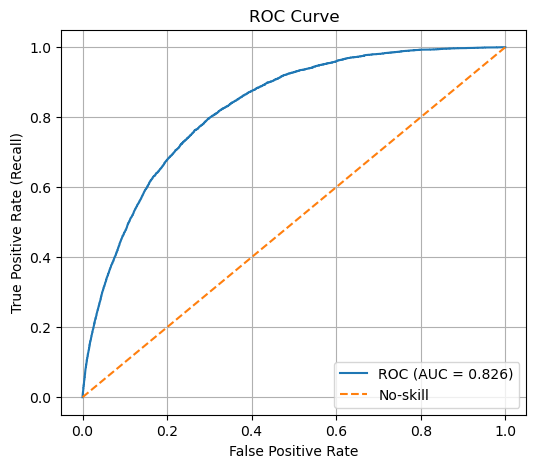

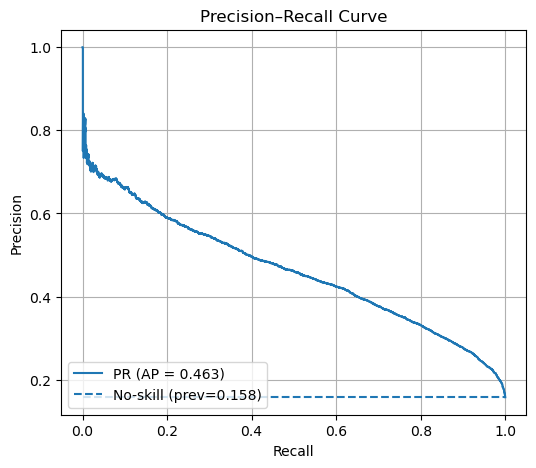

In [55]:
"""
Plot ROC and Precision–Recall curves for a classifier.

- model (pipeline or estimator) is fitted
- X_test, y_test exist

"""

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# 1) Get test-set probabilities for the positive class (class 1)
y_prob = xgb_final.predict_proba(X_test)[:, 1]

# -------------------------
# ROC curve
# -------------------------
fpr, tpr, roc_thr = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="No-skill")
# mark your tuned threshold if `thr_star` exists
if "thr_star" in locals():
    idx = int(np.argmin(np.abs(roc_thr - thr_star)))
    plt.scatter(fpr[idx], tpr[idx], marker="o", zorder=3, label=f"@ thr={thr_star:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("roc Curve-XGBoost Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()

# -------------------------
# Precision–Recall curve
# -------------------------
prec, rec, pr_thr = precision_recall_curve(y_test, y_prob, pos_label=1)
ap = average_precision_score(y_test, y_prob)
prevalence = y_test.mean()  # Random Guessing line for PR

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR (AP = {ap:.3f})")
plt.hlines(prevalence, xmin=0, xmax=1, linestyles="--", label=f"No-skill (prev={prevalence:.3f})")
# Optional: mark the tuned threshold on PR (note: len(pr_thr) = len(prec) - 1)
if "thr_star" in locals():
    idx = int(np.argmin(np.abs(pr_thr - thr_star)))
    plt.scatter(rec[idx], prec[idx], marker="o", zorder=3, label=f"@ thr={thr_star:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.savefig("PR Curve-XGBoost Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()


**Observation**

The no-skill line is what you get from random guessing with no predictive power.

ROC (AUC ≈ 0.82): Strong ranking ability—model scores true diabetics higher than non-diabetics ~ 82% of the time. At FPR ≈ 0.2 you can get recall ~0.75–0.8

PR (AP ≈ 0.46, no-skill ≈ 0.16): Good enrichment over baseline; as you push recall up, precision falls (e.g., around recall ~0.77, precision ~0.34).

Takeaway: Model separates classes well and yields meaningfully enriched alerts vs. prevalence.

For screening, pick a lower threshold to hit higher recall (accept more FPs).

<a id="interpretation-via-xgboost-Hypertuned"></a>
### Interpretation via XGBoost Hypertuned


,feature,gain
0,num__HighBP,1662.621582
1,num__HighChol,334.969177
22,num__General_Health_4,254.174484
15,num__Difficulty_Walking,239.102646
20,num__General_Health_2,176.516525
21,num__General_Health_3,176.392395
23,num__General_Health_5,150.558472
3,num__BMI,122.455902
17,num__Age_Group,110.704842
6,num__HeartDisease_or_Attack,94.502777


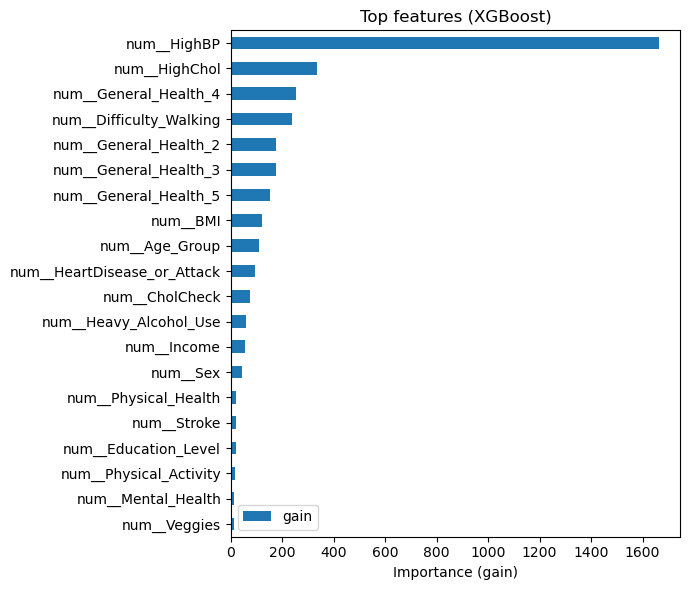

In [75]:
# --- Global importance (XGBoost "gain") ---
preproc = xgb_final.named_steps["prep"]   # ColumnTransformer
xgb     = xgb_final.named_steps["xgb"]    # trained XGBClassifier

# Names AFTER preprocessing (so they line up with the model’s inputs)
feat_out = list(preproc.get_feature_names_out())

# XGBoost reports importance by internal names 'f0','f1',...
booster = xgb.get_booster()
gain    = booster.get_score(importance_type="gain")   # 'gain' ≈ average improvement; most useful

# Map fN -> my column names
imp_df = pd.DataFrame({
    "feature": [feat_out[int(k[1:])] for k in gain.keys()],
    "gain":    [float(v) for v in gain.values()]
}).sort_values("gain", ascending=False)

display(imp_df.head(20))

# quick bar chart
ax = imp_df.head(20)[::-1].plot.barh(x="feature", y="gain", figsize=(7,6))
ax.set_xlabel("Importance (gain)"); ax.set_ylabel(""); ax.set_title("Top features (XGBoost)")
plt.tight_layout();
plt.savefig("Top features for XGBoost Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()


**Observations**

- **Gain = how much a feature improves splits on average** (global importance; not direction).
- **Top drivers:** HighBP > HighChol > General_Health_4 > Difficulty_Walking > General_Health_2/3 > BMI.
- **Also contributes:** Age_Group, HeartDisease_or_Attack, CholCheck, Heavy_Alcohol_Use, Income, Sex.
- **Lower but used:** Physical_Health, Stroke, Education_Level, Physical_Activity, Mental_Health, Veggies.
- **Note:** Importance ≠ “good/bad” effect. Use **SHAP** for direction (pushes risk up/down).


In [72]:
%pip install shap==0.44.1
import shap; shap.__version__

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 16.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   ----- ---------------------------------- 3.9/30.3 MB 21.3 MB/s eta 0:00:02
   ---------- ----------------------------- 7.9/30.3 MB 19.4 MB/s eta 0:00:02
   --------------- ------------------------ 12.1/30.3 MB 19.3 MB/s eta 0:00:01
   ------------------- -------------------- 14.9/30.3 MB 18.1 MB/s eta 0:00:01
   ----------------------- ---------------- 17.6/30.3 MB 17.0 MB/s eta 0:00:01
   ---------------------------- ----------- 21.8/30.3 MB 17.4 MB/s eta 0:00:01
   --------------------------------- ------ 25.2/30.3 MB 17.3 MB/s eta 0:00:01
   ------------------------------------- -- 28.6/30.3 MB 17.1 MB/s eta 0:00:01
   ---------------------------------------- 30.3/30.3 MB 16.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


'0.44.1'

Another technique we can use for interpretation of XGBoost is by using the SHAPs plot. This plot gives us direction to which side the risk will go based on features. 

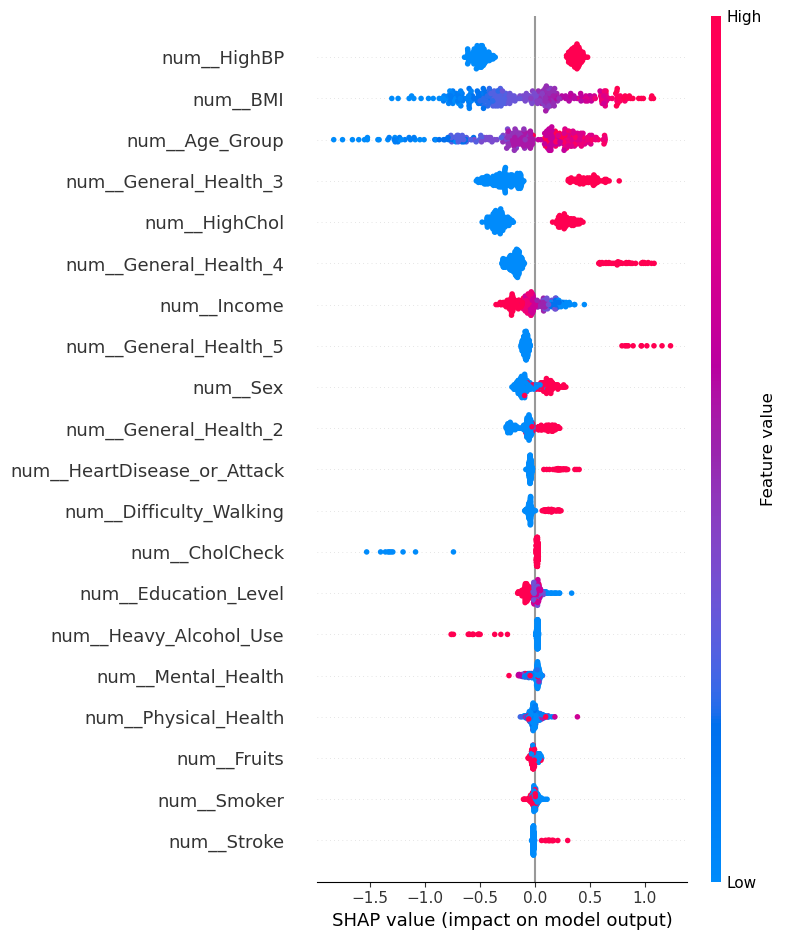

<Figure size 640x480 with 0 Axes>

In [85]:
# --- Using SHAP to explain the XGBoost model ---
import numpy as np, shap

preproc = xgb_final.named_steps["prep"]
xgb     = xgb_final.named_steps["xgb"]
feat_out = list(preproc.get_feature_names_out())

# Small background set for TreeExplainer (keeps it fast)
X_bg   = X_train.sample(min(200, len(X_train)), random_state=0)
X_eval = X_test.sample(min(300, len(X_test)), random_state=1)

X_bg_t   = preproc.transform(X_bg)
X_eval_t = preproc.transform(X_eval)

# If sparse, SHAP likes dense for plotting
if hasattr(X_bg_t, "toarray"):   X_bg_t   = X_bg_t.toarray()
if hasattr(X_eval_t, "toarray"): X_eval_t = X_eval_t.toarray()

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_eval_t)   # shape: [n_rows, n_features]

# Global view: which features push risk up/down across the dataset
shap.summary_plot(shap_values, X_eval_t, feature_names=feat_out, show=True)
plt.tight_layout()
plt.savefig("SHAP value for XGBoost Hypertuned.png", dpi=300, bbox_inches='tight')
plt.show()  


<a id="interpretation-via-xgboost-shap-plots"></a>
### Interpretation — XGBoost SHAP plots
 Global SHAP summary (beeswarm)
- **Each dot = one person**.  
- **x-axis (SHAP value)** = how much that feature pushed the prediction **up (→, higher risk)** or **down (←, lower risk)** for that person.  
- **Color** = the person’s feature value (red = high, blue = low).  
- Rows are **sorted by overall importance**.

What the plot shows
- **HighBP**, **BMI**, **Age_Group**, and **worse General_Health levels** (e.g., `General_Health_3/4/5`) strongly **increase risk** when high/true (red dots on the right).  
- **HighChol** also pushes risk up.  
- **Income** tends to pull predictions slightly down when higher (many blue/left contributions for low income vs red/near-zero for high income; the net effect is modest).  
- Some features (e.g., **CholCheck**) show **mixed** effects—these often act as proxies for other factors (age/comorbidity) and can push either direction depending on the combination of features.

> Takeaway: The model’s biggest global drivers are **blood pressure**, **BMI**, **age**, and **self-rated general health**, which aligns with clinical intuition.

---
**Notes**
- SHAP explains **associations**, not causation.  


<a id="hypertuned-model-comparison"></a>
## 9) Hypertuned Model Comparison


| Method                   | Train Type                        | Precision (Class 1) | Recall (Class 1) | F1 (Class 1) | Key Observation                                                                                                                  |
| ------------------------ | --------------------------------- | ------------------: | ---------------: | -----------: | -------------------------------------------------------------------------------------------------------------------------------- |
| **Log Reg — Hypertuned** | **Balanced**                      |            **0.34** |         **0.77** |     **0.47** | **Accuracy 0.73.** Best among baselines for recall; interpretable with expected precision trade-off.                             |
| **XGBoost — Baseline**   | **Original**                      |            **0.34** |         **0.79** |     **0.47** | **Accuracy 0.72.** Strong class-1 recall (slightly higher than LR tuned) with lower precision.                                   |
| **XGBoost — Hypertuned** | **Weighted (scale_pos_weight)** |            **0.34**🏆 |         **0.79**🏆 |     **0.47** 🏆| **Accuracy 0.72;  Strongest recall with expected precision trade-off; best overall discrimination. |


**Summary**

Who wins?

It all depends on the final objective. If the models main aim to to catch more positives, then XGBoost is good. But if we need a simple yet interpretable model with nearly the same perforamnce, Logistic Regression is better.

Both models are very close. XGBoost edges LR on recall, ROC AUC, and PR AUC; LR is slightly higher on accuracy and is more interpretable.

Why XGBoost beats LR here ?

**Non-linearities & interactions**: 
- Gradient boosting trees capture splits/feature interactions LR can’t without manual feature engineering.

**Class imbalance handled well**: 
- scale_pos_weight = neg/pos pushes trees to pick up minority patterns; with one-hot encoding, categorical effects are modeled flexibly.

**Better PR AUC**: 
- PR AUC focuses on positive class performance; the gain suggests XGB finds more true diabetics at similar precision.



## 10) <a id="conclusion"></a> Conclusion

I started by diagnosing class imbalance and addressing it consistently throughout modeling. I compared multiple baselines and decided that recall for the positive (diabetic) class is the most important metric. Across models, I found that class weights and random upsampling produced nearly identical results.Upsampling was strictly only done on training data; test untouchedThe recall for Random Forest & KNN improved slightly. That is expected: upsampling duplicates minority examples (stronger presence in the loss), while class weights amplify their loss contribution. For convex learners like Logistic Regression—and even for tree ensembles in practice—those two approaches push the decision boundary in very similar ways.

The final winner was **XGBoost** and that will be used for further development work 



### <a id="key-takeaways"></a> Key Takeaways

- Both Hypertuned Logistic Regression and Hypertuned XGBoost perform well on this imbalanced diabetes task and produce very similar ranking quality. XGBoost shows a small edge in minority-class recall and PR AUC, while Logistic Regression delivers nearly the same performance with higher interpretability and slightly higher accuracy

- Class imbalance handled effectively: class_weight='balanced' (LR) and scale_pos_weight (XGB) performed comparably to upsampling—consistent with theory, since both increase the effective influence of the minority class.
- Best screening choice: XGBoost (Recall≈0.79, AP≈0.463) catches the most positives with modest precision (~0.34).

- Best interpretable choice: Logistic Regression (Recall≈0.77, AP≈0.431) is simpler to explain and nearly as good; accuracy is slightly higher (≈0.73 vs 0.72).



*Recomended next steps*:

- Try stacking of 2 best models (LR+ XGBoost)
- Collect latest data and check for this MLs robustness
- Try Neural Networks
- Try threshold tuning



## Appendix-Streamlit

In [56]:
# Get all expected columns after preprocessing
expected_cols = X_train.columns.tolist()
print(expected_cols)


['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDisease_or_Attack', 'Physical_Activity', 'Fruits', 'Veggies', 'Heavy_Alcohol_Use', 'AnyHealthcare', 'Doctor_unavailable_cost', 'Mental_Health', 'Physical_Health', 'Difficulty_Walking', 'Sex', 'Age_Group', 'Education_Level', 'Income', 'General_Health_2', 'General_Health_3', 'General_Health_4', 'General_Health_5']


In [57]:
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib

SEED = 101

# 1) Rebuild the exact preprocessing you used at training
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns
cat_cols = X_train.select_dtypes(exclude=["number", "bool"]).columns

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)

# 2) Build the full pipeline (preprocess -> XGB)
xgb_final = Pipeline([
    ("prep", preprocess),   # <- ColumnTransformer object (NOT a string)
    ("xgb", XGBClassifier(
        random_state=SEED,
        tree_method="hist",
        n_estimators=600,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric="logloss",
    )),
])

# 3) Fit (if not already fitted)
xgb_final.fit(X_train, y_train)

# Optional sanity check before saving
from sklearn.compose import ColumnTransformer
print(type(xgb_final.named_steps["prep"]))   # should be <class 'sklearn.compose._column_transformer.ColumnTransformer'>

# 4) Save the FULL pipeline
joblib.dump(xgb_final, "xgb_diabetes_model.pkl")
print("Saved pipeline to xgb_diabetes_model.pkl")


<class 'sklearn.compose._column_transformer.ColumnTransformer'>
Saved pipeline to xgb_diabetes_model.pkl


In [59]:
# after fitting final_lr on the full train set
from joblib import dump
import os
os.makedirs("models", exist_ok=True)
dump(final_lr, "models/lr_pipeline.joblib")
print("saved to models/lr_pipeline.joblib")


saved to models/lr_pipeline.joblib


In [63]:
from pathlib import Path
import pandas as pd, numpy as np
import joblib, pickle

# --- locate the model file robustly ---
CANDIDATES = [
    Path("models/xgb_diabetes_model.pkl"),
    Path("xgb_diabetes_model.pkl"),
    Path.home() / "OneDrive" / "Desktop" / "Streamlit-Diabetes" / "xgb_diabetes_model.pkl",
    Path("uploaded_model.joblib"),   # if you saved another name
]
MODEL_FILE = next((p for p in CANDIDATES if p.exists()), None)
if MODEL_FILE is None:
    raise FileNotFoundError("Couldn't find the model. Update CANDIDATES with the correct path.")

# --- load with joblib, fallback to pickle ---
try:
    pipe = joblib.load(MODEL_FILE)
except Exception:
    with open(MODEL_FILE, "rb") as f:
        pipe = pickle.load(f)

# --- get probabilities on your held-out set ---
# X_test / y_test must come from your earlier split and have the same columns the model expects
proba = pipe.predict_proba(X_test)[:, 1]

# --- build the eval file for the dashboard ---
eval_df = pd.DataFrame({
    "y_true": pd.Series(y_test).astype(int).values,
    "proba":  proba,
})

# include some columns for cohort slices if they exist in X_test
cols_for_slices = ["BMI","Age","GenHlth","HighBP","HighChol","PhysActivity","Smoker"]
for c in cols_for_slices:
    if c in getattr(X_test, "columns", []):
        eval_df[c] = X_test[c].values

# save to repo-relative data/ folder
out_dir = Path("data")
out_dir.mkdir(exist_ok=True)
eval_df.to_csv(out_dir / "eval.csv", index=False)

print("Saved:", out_dir / "eval.csv")
print("Rows:", len(eval_df))


Saved: data\eval.csv
Rows: 50736


In [62]:
from pathlib import Path
print("Notebook working directory:\n", Path.cwd().resolve())


Notebook working directory:
 C:\Users\LENOVO\OneDrive\Desktop\Brainstation\Unit 2\Python 1
